In [6]:
import xarray as xr
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from importlib import reload
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import data_processing

In [2]:
h2o_data = xr.open_dataset('ACEFTS_L2_v5p2_H2O.nc')
h2o_flags = xr.open_dataset('ACEFTS_L2_v5p2_flags_H2O.nc')

In [3]:
h2o_data = h2o_data.set_index(index=['orbit', 'sunset_sunrise'])
h2o_flags = h2o_flags.set_index(index=['orbit', 'sunset_sunrise'])

In [4]:
def encode_time_features(year, month, day, hour):
    month_sin = np.sin(2 * np.pi * month / 12)
    month_cos = np.cos(2 * np.pi * month / 12)
    day_sin = np.sin(2 * np.pi * day / 31)
    day_cos = np.cos(2 * np.pi * day / 31)
    hour_sin = np.sin(2 * np.pi * hour / 24)
    hour_cos = np.cos(2 * np.pi * hour / 24)
    year_normalized = (year - 2004) / (20)
    return [year_normalized, month_sin, month_cos, day_sin, day_cos, hour_sin, hour_cos]

In [7]:
reload(data_processing)
import data_processing
from data_processing import preprocess_profile_data as ppd

In [8]:
date_indices = np.arange(len(h2o_data['year'].values))

In [9]:
features, labels = ppd('H2O', h2o_data, h2o_flags, date_indices, n_surrounding = 4, n_altitudes = len(h2o_data['altitude'].values))

BUG: VMR for date index 256 is empty after screening. Surrounding indices: [np.int64(252), np.int64(253), np.int64(254), np.int64(255), np.int64(256)]


ValueError: zero-size array to reduction operation maximum which has no identity

In [ ]:
features.shape

(125194, 5, 150, 9)

In [10]:
from keras import layers, models

In [11]:
from keras.optimizers import Adam

optimizer = Adam(learning_rate=1e-4)  # Lower the learning rate

In [12]:
import tensorflow as tf

def binary_accuracy_with_threshold(y_true, y_pred):
    """
    Custom accuracy metric for binary classification with a threshold.
    """
    y_pred_discrete = tf.cast(y_pred > 0.5, tf.float32)
    return tf.keras.metrics.binary_accuracy(y_true, y_pred_discrete)

In [ ]:
from keras.optimizers import Adam

optimizer = Adam(learning_rate=1e-4)  # Lower the learning rate

# Define the CNN-LSTM model
def build_cnn_lstm_model(n_profiles, n_altitudes, n_features):
    """
    Builds a CNN-LSTM model for profile classification.

    Parameters:
    - n_profiles: Number of profiles per sample.
    - n_altitudes: Number of altitude levels per profile.
    - n_features: Number of features per altitude.

    Returns:
    - model: Compiled CNN-LSTM model.
    """
    input_shape = (n_profiles, n_altitudes, n_features)

    # Input layer
    inputs = tf.keras.Input(shape=input_shape)

    # Time-distributed CNN layers
    cnn = layers.TimeDistributed(
        models.Sequential([
            layers.Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(n_altitudes, n_features)),
            layers.MaxPooling1D(pool_size=2),
            layers.Conv1D(filters=128, kernel_size=3, activation='relu'),
            layers.MaxPooling1D(pool_size=2),
            layers.Flatten()
        ])
    )(inputs)

    # LSTM layers
    lstm = layers.LSTM(128, return_sequences=False)(cnn)

    # Fully connected layers
    dense = layers.Dense(64, activation='relu')(lstm)
    outputs = layers.Dense(1, activation='sigmoid')(dense)  # Binary classification

    # Build the model
    model = models.Model(inputs=inputs, outputs=outputs)

    # Compile the model
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=[binary_accuracy_with_threshold])

    return model


In [33]:
n_profiles = 5
n_altitudes = len(h2o_data['altitude'].values)
n_features = 9

model = build_cnn_lstm_model(n_profiles, n_altitudes, n_features)

/Users/jamesharvey/MPhys_Project/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
from keras._tf_keras.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [34]:
# Split the data into training, validation, and test sets
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(features, labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [35]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

In [140]:
import numpy as np

# Compute raw class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Apply logarithmic scaling
smoothed_weights = np.log1p(class_weights)

# Convert to dictionary for Keras
class_weights_dict = {i: smoothed_weights[i] for i in range(len(smoothed_weights))}

In [141]:
intermediate_weights = (class_weights + smoothed_weights)/2

class_weights_dict = {i: intermediate_weights[i] for i in range(len(intermediate_weights))}

Epoch 1/30
2739/2739 ━━━━━━━━━━━━━━━━━━━━ 111s 40ms/step - binary_accuracy_with_threshold: 0.6066 - loss: 0.6829 - val_binary_accuracy_with_threshold: 0.5451 - val_loss: 0.6701
Epoch 2/30
2739/2739 ━━━━━━━━━━━━━━━━━━━━ 109s 40ms/step - binary_accuracy_with_threshold: 0.5237 - loss: 0.6763 - val_binary_accuracy_with_threshold: 0.3304 - val_loss: 0.7380
Epoch 3/30
2739/2739 ━━━━━━━━━━━━━━━━━━━━ 114s 42ms/step - binary_accuracy_with_threshold: 0.5229 - loss: 0.6677 - val_binary_accuracy_with_threshold: 0.5628 - val_loss: 0.6638
Epoch 4/30
2739/2739 ━━━━━━━━━━━━━━━━━━━━ 114s 41ms/step - binary_accuracy_with_threshold: 0.5654 - loss: 0.6526 - val_binary_accuracy_with_threshold: 0.4687 - val_loss: 0.7240
Epoch 5/30
2739/2739 ━━━━━━━━━━━━━━━━━━━━ 117s 43ms/step - binary_accuracy_with_threshold: 0.5846 - loss: 0.6526 - val_binary_accuracy_with_threshold: 0.5423 - val_loss: 0.6848
Epoch 6/30
2739/2739 ━━━━━━━━━━━━━━━━━━━━ 120s 44ms/step - binary_accuracy_with_threshold: 0.5978 - loss: 0.6394 - 

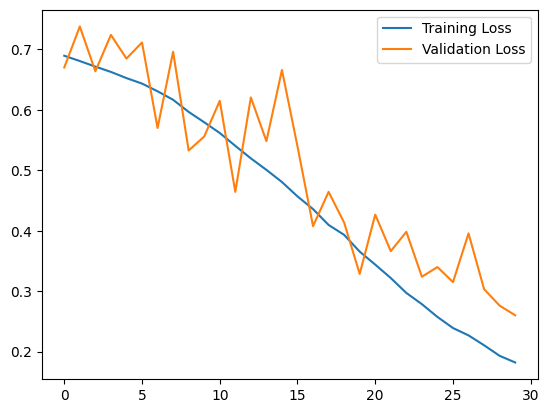

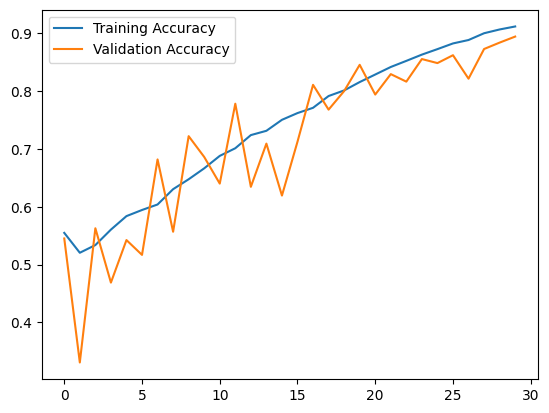

In [36]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    class_weight=class_weight_dict
)

plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['binary_accuracy_with_threshold'], label='Training Accuracy')
plt.plot(history.history['val_binary_accuracy_with_threshold'], label='Validation Accuracy')
plt.legend()
plt.show()

587/587 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step
              precision    recall  f1-score   support

           0       0.99      0.90      0.94     18176
           1       0.19      0.66      0.29       604

    accuracy                           0.90     18780
   macro avg       0.59      0.78      0.62     18780
weighted avg       0.96      0.90      0.92     18780



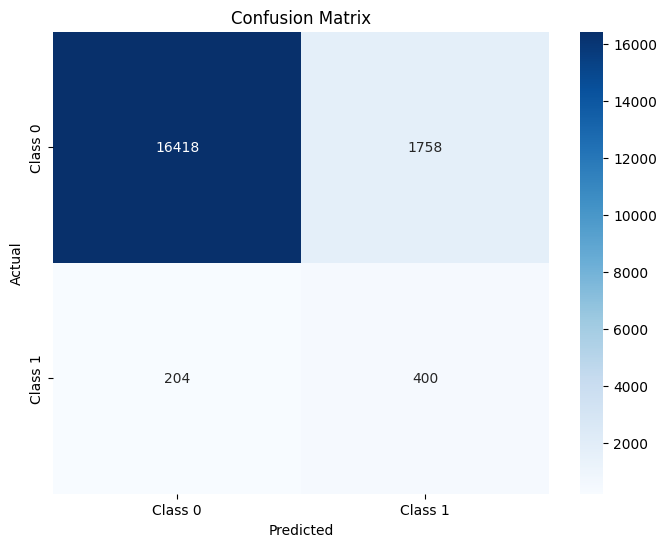

In [37]:
# Get predictions
predictions = model.predict(X_test)

# Convert probabilities to discrete labels
discrete_predictions = (predictions > 0.5).astype(int)

# Print classification report
print(classification_report(y_test, discrete_predictions))

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, discrete_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [24]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

587/587 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - binary_accuracy_with_threshold: 0.7806 - loss: 0.4861
Test Loss: 0.48358792066574097, Test Accuracy: 0.7832268476486206


In [25]:
years = h2o_data['year'].values
months = h2o_data['month'].values
days = h2o_data['day'].values
hours = h2o_data['hour'].values
times = pd.to_datetime({
    'year': years,
    'month': months,
    'day': days,
    'hour': hours
})

In [26]:
bad_profile_indices = []
for i in range(0, len(times)-1):
    orbit_number = h2o_data['orbit'][i].values
    ss = h2o_data['sunset_sunrise'][i].values

    try:
        flag_profile = h2o_flags['quality_flag'].sel(orbit=orbit_number, sunset_sunrise=ss).values
        if ((flag_profile != 0) & (flag_profile != 8) & (flag_profile != 9)).any():
            bad_profile_indices.append(i)
    except KeyError:
        print(f"Skipping missing orbit/sunset_sunrise pair: orbit={orbit_number}, sunset_sunrise={ss}")
        continue

Skipping missing orbit/sunset_sunrise pair: orbit=110807.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=110955.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=111363.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=111430.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=111444.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=111445.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=111466.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=112226.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=112505.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=112518.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=112525.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=112526.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=11

In [27]:
bad_features, bad_labels = ppd('H2O', h2o_data, h2o_flags, bad_profile_indices, n_surrounding = 2, n_altitudes = len(h2o_data['altitude'].values))

Skipping due to instrumental error: orbit=29089.0, sunset_sunrise=1.0
Skipping due to instrumental error: orbit=29143.0, sunset_sunrise=1.0
Skipping due to instrumental error: orbit=29147.0, sunset_sunrise=1.0
Skipping due to instrumental error: orbit=29175.0, sunset_sunrise=1.0
Skipping due to instrumental error: orbit=29178.0, sunset_sunrise=1.0
Skipping due to instrumental error: orbit=29179.0, sunset_sunrise=1.0
Skipping due to instrumental error: orbit=29195.0, sunset_sunrise=1.0
Skipping due to instrumental error: orbit=29219.0, sunset_sunrise=1.0
Skipping due to instrumental error: orbit=29263.0, sunset_sunrise=1.0
Skipping due to instrumental error: orbit=29267.0, sunset_sunrise=1.0
Skipping due to instrumental error: orbit=29268.0, sunset_sunrise=1.0
Skipping due to instrumental error: orbit=29294.0, sunset_sunrise=1.0
Skipping due to instrumental error: orbit=29296.0, sunset_sunrise=1.0
Skipping due to instrumental error: orbit=29304.0, sunset_sunrise=1.0
Skipping due to inst

In [28]:
test_loss, test_accuracy = model.evaluate(bad_features, bad_labels)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - binary_accuracy_with_threshold: 0.8448 - loss: 0.3934
Test Loss: 0.37135571241378784, Test Accuracy: 0.8633663654327393
